In [1]:
!pip install faiss-cpu

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import faiss
from mpl_toolkits.mplot3d import Axes3D
import time

In [3]:
def generate_sample_vectors(n_vectos:int = 100, n_dimensions:int = 3, seed:int = 42):
    '''
    Generating syenthetic vectors
    '''
    np.random.seed(seed)
    vectors = np.random.randn(n_vectos,n_dimensions)
    normalized_vectores = normalize(vectors,norm='l2')
    return normalized_vectores

In [4]:
 def plot_vectors_3d(vectors, query_vector=None, matches=None, title="Vector Space Visualization"):
    """Basic 3D visualization without regions."""
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot all vectors
    ax.scatter(vectors[:, 0], vectors[:, 1], vectors[:, 2], c='blue', alpha=0.5, label='Database vectors')
    
    # Plot query vector if provided
    if query_vector is not None:
        ax.scatter(query_vector[0], query_vector[1], query_vector[2], 
                  c='red', s=100, label='Query vector')
    
    # Plot matches if provided
    if matches is not None:
        match_vectors = vectors[matches]
        ax.scatter(match_vectors[:, 0], match_vectors[:, 1], match_vectors[:, 2], 
                  c='green', s=100, label='Matches')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend()
    plt.show()

def plot_vectors_with_regions(vectors, centroids, query_vector=None, matches=None, 
                            searched_regions=None, title="Vector Space with FAISS Regions"):
    """
    Visualize vectors in 3D space with their clusters/regions.
    """
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    # Assign each vector to nearest centroid
    distances, assignments = compute_vector_assignments(vectors, centroids)
    
    # Plot vectors colored by their cluster
    colors = plt.cm.rainbow(np.linspace(0, 1, len(centroids)))
    for i in range(len(centroids)):
        cluster_vectors = vectors[assignments == i]
        if len(cluster_vectors) > 0:
            # Make vectors transparent if their region wasn't searched
            alpha = 1.0 if searched_regions is None or i in searched_regions else 0.1
            ax.scatter(cluster_vectors[:, 0], cluster_vectors[:, 1], cluster_vectors[:, 2], 
                      c=[colors[i]], alpha=alpha, label=f'Region {i}')
    
    # Plot centroids
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], 
              c='black', s=100, marker='*', label='Region Centers')
    
    # Plot query vector
    if query_vector is not None:
        ax.scatter(query_vector[0], query_vector[1], query_vector[2], 
                  c='red', s=200, marker='x', label='Query Vector')
    
    # Plot matches
    if matches is not None:
        match_vectors = vectors[matches]
        ax.scatter(match_vectors[:, 0], match_vectors[:, 1], match_vectors[:, 2], 
                  c='green', s=100, label='Matches')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend()
    plt.show()

In [5]:
def compute_vector_assignments(vectors, centroids):
    """Compute which vectors belong to which centroids."""
    index = faiss.IndexFlatL2(vectors.shape[1])
    index.add(centroids)
    distances, assignments = index.search(vectors, 1)
    return distances, assignments.ravel()

def train_kmeans_get_centroids(vectors, n_clusters):
    """Train k-means and get centroids."""
    kmeans = faiss.Kmeans(d=vectors.shape[1], k=n_clusters, niter=20, verbose=False)
    kmeans.train(vectors)
    return kmeans.centroids


In [6]:
def brute_force_cosine_search(database_vectors, query_vector, k=5):
    """Perform brute force cosine similarity search."""
    start_time = time.time()
    similarities = np.dot(database_vectors, query_vector)
    top_k_indices = np.argsort(similarities)[-k:][::-1]
    end_time = time.time()
    return top_k_indices, end_time - start_time

def faiss_flat_l2_search(database_vectors, query_vector, k=5):
    """Perform basic FAISS L2 search (no regions)."""
    dimension = database_vectors.shape[1]
    index = faiss.IndexFlatL2(dimension)
    
    start_time = time.time()
    index.add(database_vectors)
    distances, indices = index.search(query_vector.reshape(1, -1), k)
    end_time = time.time()
    
    return indices[0], end_time - start_time


In [7]:
def faiss_ivf_search_realistic(database_vectors, query_vectors, k=5, n_regions=10, nprobe=3):
    """
    More realistic FAISS IVF search that:
    - Separates training time from search time
    - Handles batch queries
    
    Consider changing function name later as this was named while experimenting with various scenarios
    """
    dimension = database_vectors.shape[1]
    
    # Create and train index (this would normally be done once and saved)
    print("Training index (this is usually done once)...")
    quantizer = faiss.IndexFlatL2(dimension)
    index = faiss.IndexIVFFlat(quantizer, dimension, n_regions, faiss.METRIC_L2)
    
    train_start = time.time()
    index.train(database_vectors)
    train_time = time.time() - train_start
    
    # Add vectors (this is also usually done once)
    add_start = time.time()
    index.add(database_vectors)
    add_time = time.time() - add_start
    
    # Set number of regions to search
    index.nprobe = nprobe
    
    # Actual search (this is what we'd do many times)
    search_start = time.time()
    distances, indices = index.search(query_vectors, k)
    search_time = time.time() - search_start
    
    return indices, search_time, train_time, add_time

Generating 1000 vectors with 3 dimensions...

Visualizing initial vector space...


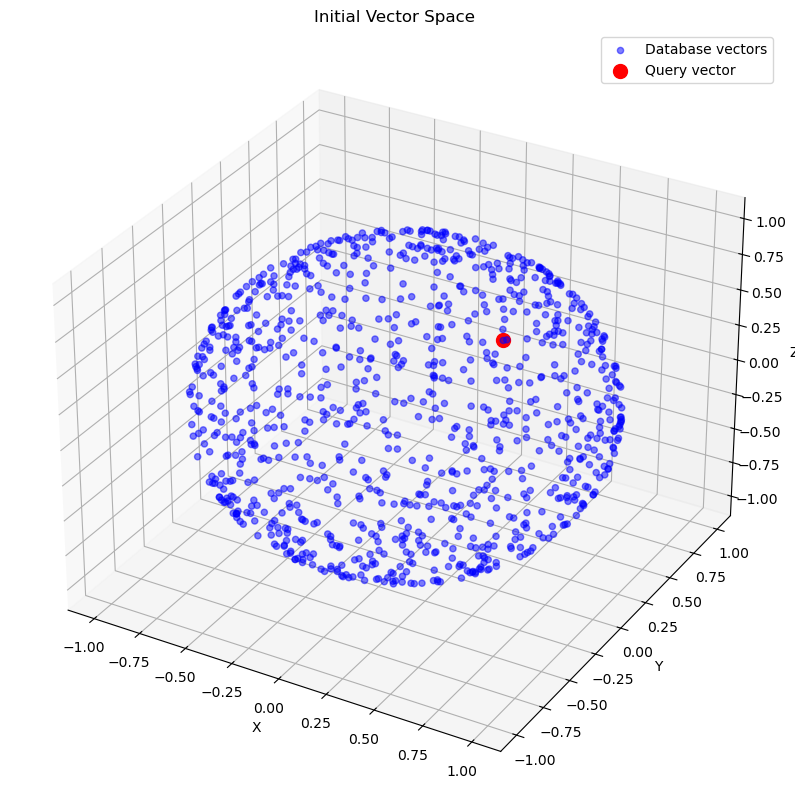

In [8]:
n_vectors = 1000
n_dimensions = 3  # Using 3D for visualization
k = 5
print(f"Generating {n_vectors} vectors with {n_dimensions} dimensions...")
database_vectors = generate_sample_vectors(n_vectors, n_dimensions)

# 2. Generate a random query vector
query_vector = generate_sample_vectors(1, n_dimensions)[0]
query_vector_batch = query_vector.reshape(1, -1)  # Reshape for batch processing

# 3. Visualize initial vector space
print("\nVisualizing initial vector space...")
plot_vectors_3d(database_vectors, query_vector, title="Initial Vector Space")



Performing brute force cosine similarity search...
Brute force search time: 0.000167 seconds
Top 5 cosine similarity matches (indices): [  0 653  61 273 336]


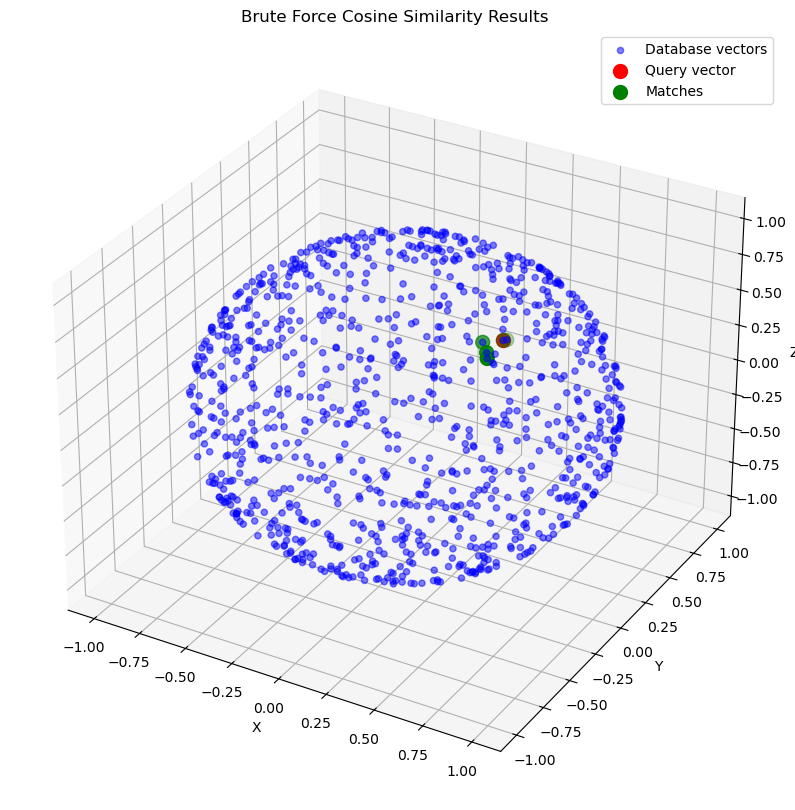

In [9]:
print("\nPerforming brute force cosine similarity search...")
cosine_matches, cosine_time = brute_force_cosine_search(database_vectors, query_vector, k)
print(f"Brute force search time: {cosine_time:.6f} seconds")
print(f"Top {k} cosine similarity matches (indices): {cosine_matches}")

# 5. Visualize cosine results
plot_vectors_3d(database_vectors, query_vector, cosine_matches, 
               "Brute Force Cosine Similarity Results")



Performing basic FAISS L2 search...
FAISS L2 search time: 0.001164 seconds
Top 5 L2 distance matches (indices): [  0 653  61 273 336]


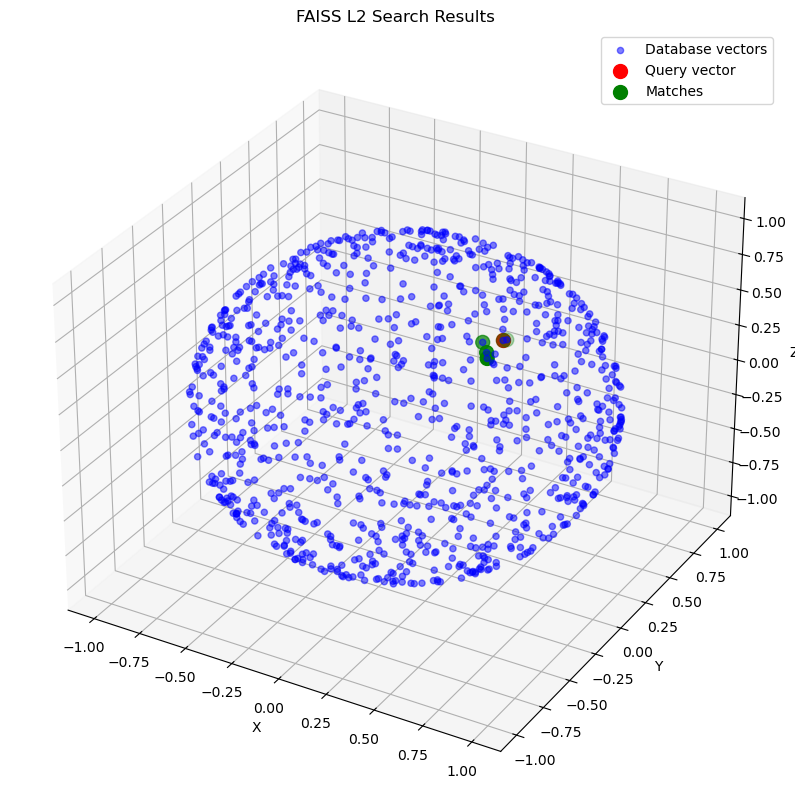

In [10]:
print("\nPerforming basic FAISS L2 search...")
faiss_matches, faiss_time = faiss_flat_l2_search(database_vectors, query_vector, k)
print(f"FAISS L2 search time: {faiss_time:.6f} seconds")
print(f"Top {k} L2 distance matches (indices): {faiss_matches}")

# 7. Visualize basic FAISS results
plot_vectors_3d(database_vectors, query_vector, faiss_matches, 
               "FAISS L2 Search Results")

In [ ]:
print("\nPerforming FAISS IVF search with regions...")
n_regions = 10
nprobe = 3

# Create and train index
dimension = database_vectors.shape[1]
quantizer = faiss.IndexFlatL2(dimension)
index = faiss.IndexIVFFlat(quantizer, dimension, n_regions, faiss.METRIC_L2)

print("Training index...")
train_start = time.time()
index.train(database_vectors)
train_time = time.time() - train_start
print(f"Training time: {train_time:.6f} seconds")

print("Adding vectors...")
add_start = time.time()
index.add(database_vectors)
add_time = time.time() - add_start
print(f"Adding time: {add_time:.6f} seconds")
